# Import Packages

In [1]:
## usual impport functions : general use
import numpy as np
from numpy import cosh, zeros_like, mgrid, zeros
import matplotlib.pyplot as plt
import pandas as pd
import math

# from interpolation.complete_poly import (CompletePolynomial,
#                                          n_complete, complete_polynomial,
#                                          complete_polynomial_der,
#                                          _complete_poly_impl,
#                                          _complete_poly_impl_vec,
#                                          _complete_poly_der_impl,
#                                          _complete_poly_der_impl_vec)
from numba import jit, vectorize, njit, prange

## scipy functions for optimization (not all used)
import scipy.optimize as opt
from scipy.optimize import root
from scipy.sparse import spdiags, kron
from scipy.sparse.linalg import spilu, LinearOperator, eigs
from scipy.optimize import leastsq
from scipy.optimize import minimize
from scipy.special import j1
from scipy.sparse import lil_matrix, coo_matrix
from scipy.interpolate import interp1d ## 1d interpolation, 2d and radial basis are avaiable for higher dimension interpolation
from typing import NamedTuple, Callable
from collections import namedtuple
from scipy.special import roots_hermite
from scipy.interpolate import RegularGridInterpolator


from concurrent.futures import ProcessPoolExecutor
from multiprocessing import Pool
import requests
import time
from time import time

from mpl_toolkits.mplot3d import Axes3D


from dataclasses import dataclass
from numpy.linalg import eig

import os
print(f"Available CPUs: {os.cpu_count()}")
### quantecon functions
# import quantecon as qe
# import quantecon_wasm as qe_w
# from quantecon import compute_fixed_point
# from quantecon.markov import DiscreteDP

Available CPUs: 2


# Functions

In [2]:
## rouwenhorst method

## AR process - yt = (1- rho)*y_bar + rho*yt + et, sigma_e

def rouwenhorst_matrix(params):
  p = (1+params.rho)/2
  q = p

  mat_temp=np.array([[p,1-p],[1-q,q]])
  sigma_y = params.sigma / np.sqrt(1 - params.rho**2)
  delta = sigma_y*np.sqrt(params.nbn-1)


  for i in range(params.nbn-2):
    a = mat_temp.shape[0]
    mat_temp_next = np.zeros((a+1,a+1))
    mat_temp_next[:a,:a] += p*mat_temp
    mat_temp_next[:a,1:] += (1-p)*mat_temp
    mat_temp_next[1:,:a] += (1-p)*mat_temp
    mat_temp_next[1:,1:] += p*mat_temp
    mat_temp = mat_temp_next
    mat_temp[1:a,:] = mat_temp[1:a,:]/2

  return mat_temp, delta


def stationary_distribution(Pi):

  vals, vecs = np.linalg.eig(Pi)
  index = np.argmin(np.abs(vals - 1.0))
  pi = vecs[:, index].real
  pi = pi / np.sum(pi)

  return pi


def stationary_distribution_stable(Pi,initial, max_iter=1000,tol = 1e-07):
  pi = initial
  for _ in range(max_iter):
    pi_new = Pi.T @ pi
    if np.max(np.abs(pi_new - pi)) < tol:
        return pi_new
    pi = pi_new

  return pi


def discretize_state(params):
  p = (1+params.rho)/2
  Pi , delta = rouwenhorst_matrix(params)         ## discretize a log normal AR process so exp
  z = np.exp(np.linspace(-delta, delta, params.nbn))
  N = Pi.shape[0]
  initial = np.ones(N) / N  # start uniform
  pi = stationary_distribution_stable(Pi,initial)

  return Pi, pi, z

## functions


def f(params,k,z):
  return z*k**(params.alpha)


def fprime(params,k,z):
  return z*params.alpha*k**(params.alpha-1)


def u_c(params,c):
  if params.gamma == 1:
    return np.log(c)
  else:
    return c**(params.gamma-1)/(params.gamma-1)


def mu_c(params,c):
  return c**(-params.gamma)


def mu_c_inv(params,y):
  return y** (-1/params.gamma)


def chebyshev_grid(k_min, k_max, N):
    x = chebyshev_nodes(N)              # in [-1,1]
    return 0.5*(k_max - k_min)*(x + 1) + k_min


def cheby_pol(kz, order): ## chebyshev polynomial - usual
  N = len(kz)                     ## Chebypol = chebvander(vChebynodes, ChebyOrder) - alternative
  T = np.zeros((N, order+1))
  T[:,0] = 1

  if order >= 1:
    for i in range(N):
      T[i,1] = kz[i]
## cheby recursion
  for n in range(1, order):
    for i in range(N):
      T[i,n+1] = 2*kz[i]*T[i,n] - T[i,n-1]
  return

## functions necessary

def chebyshev_nodes(n):
  return np.cos((2*np.arange(1,n+1)+1)*np.pi/(2*n+2)) ## return n sized chebyshev nodes (n*1)


def chebyshev_approx(kappa, x):
    return chebval(x, kappa)  ### return the chebyshev function numerical value with known cheby coefficients


def chebyshev_coefficients(c_values, x_nodes, order = 3):
    """
    c_values: values of the policy function at Chebyshev nodes
    order: maximum polynomial order N. default is 3
    x_nodes: Chebyshev nodes on [-1,1]
    """
    coeffs = np.zeros(order+1)
    for p in range(order+1):
        Tp = np.cos(p * np.arccos(x_nodes))  # Chebyshev polynomial at nodes
        coeffs[p] = np.sum(c_values * Tp) / np.sum(Tp**2)
    return coeffs

# def combine_cheby(k_cheby,z_cheby):
#   k_num= k_cheby.size
#   z_num= z_cheby.size
#   max_num = max(k_num, z_num)
#   logc = np.zeros(max_num)
#   for i in range(k_num):
#     for j in range(z_num)

# Parameteres

In [ ]:


## namedtuple works with numba - dictionary not compliant with that
Params = namedtuple("Params", ["r", "alpha",
                               "beta",
                               "delta",
                               "gamma",   ## IES
                               "rho",
                               "sigma",
                                "k_min",  # borrowing constraint
                               "nbk",           ## grid size  - needed for time iteration or egm
                                "k_max",
                                "nbn", ## number of states of discretized state space
                               "n_bar",
                               "rou",
                               "B",
                               "Xbar",
                               "sh_rho",

                               "y1",
                               "y2",
                               "la1"
                               "la2"
                                  ])

params = Params(
    beta=0.96,
     delta = 1,
    gamma=1,
    alpha=1/3,
    rho=0.9,
    sigma=0.2,
    r=0.03,
    k_min=0,                ## assest/capital in log - lower bound is 0 not inclusive
    k_max=100,
    nbk= 500,
    nbn = 7,
    n_bar = 1,            ## makes it 0 anyways
    rou = 1,
    B = 2,              ## no of bonds
    Xbar = 1,               ## mean productivity
    sh_rho = 0.95         ## AR shock values for MIT shock


    y1 = 0,
    y2 = 1,
    la1 = 0.03,
    la2 = 0.02





)


In [ ]:
1/params.beta - 1

## steady state distribution exists for r only less than this below

0.04166666666666674

# Hugett model

## VFI

In [ ]:
class HM:
  def __init__(self,params):
    self.params = params


  def create_grid(self):

    penalty = 10**16;
    epsilon = np.finfo(float).eps

    ## non linear grid
    # a_uniform = np.linspace(0, 1, params.nbk).reshape(-1, 1)
    # a_transformed = a_uniform**2
    # a = params.k_min + (params.k_max - params.k_min) * a_transformed

    ubar = np.log(1 + np.log(1 + params.k_max - params.k_min))
    a_uniform = np.linspace(0, ubar, params.nbk)
    a = params.k_min + np.exp(np.exp(a_uniform) - 1) - 1


    amatrix = np.tile(a,(1,params.nbk))
    amatrix_t = amatrix.T




    ## consumption matrix
    common_base_term = (1+params.r)*amatrix - amatrix_t

    ## continous state/ discrete state
    if params.rou == 1:
      Pi, pi, y = discretize_state(self.params)
    else:
      Pi, y = params.Pi, params.y
    ## c and u matrix
    n_y = len(y)
    cmatrix = np.zeros((n_y, params.nbk, params.nbk))
    umatrix = np.zeros_like(cmatrix)

    for i in range(n_y):
      cmatrix[i] = common_base_term + y[i]
      ## violations and penalty
      violations = (cmatrix[i]<=0)
      cmatrix[i] = cmatrix[i]*(cmatrix[i]>0) + epsilon

      if params.gamma == 1:
        umatrix[i] = np.log(cmatrix[i])
      else:
        umatrix[i] = (cmatrix[i]**(1-params.gamma)-1)/(1-params.gamma)

    return Pi, pi, y, a, cmatrix, umatrix


  def SVFI_HM(self,params, tol = 10**-6, max_iter = 1000):

    Pi,pi,y, self.a, self.cmatrix, self.umatrix = self.create_grid()
    ## return the policy functions through njit class
    return solver_HM(self.a,
            self.cmatrix,
            self.umatrix,
            Pi,
                     pi,
            y,
            params.beta,
            params.nbk,
            params.r,
            tol,
            max_iter)


In [ ]:
#@njit(parallel = True)

def solver_HM(a, cmatrix, umatrix, Pi,pi,y, beta, nbk, r, tol = 10**-6, max_iter = 1000):

    iterr = 0                                     ## initialise iterations
    crit = 1                                     ## convergence criterion

    ## value function iteration : basic - based on matrix of k, c and u: i th row = current capital and j th column = next period capital
    n_y = len(y)

    ## initialize as 0 value  v_0[:,0]
    v_0 = np.zeros((nbk,n_y))
    v_1 = np.zeros_like(v_0)
    a_policy = np.empty_like(v_0)
    c_policy =np.empty_like(v_0)
    pol_idx = np.empty_like(v_0,dtype =int)


    ## loop for vfi
    while crit > tol and iterr < max_iter:

      for i in prange(n_y):
        ## bellman operator
        EV = v_0 @ Pi[i,:]
        bellman_rhs = umatrix[i] + beta*EV[None, :]

        ## bellman maximisation along row
        v_1[:,i] = np.max(bellman_rhs,axis=1)

        ## bellman maximisation along row - index of the maximiser
        pol_idx[:,i] = np.argmax(bellman_rhs, axis=1)

      ## bellman convergence
      crit = np.max(np.abs(v_1 - v_0))

      v_0[:] = v_1  ## important for memory allocation - not pointing to a new variable, memory allocation done earlier remains intact
      iterr += 1
    print("done after iterations :{}".format(iterr))


    ## policy function
    for i in range(n_y):
      a_policy[:,i] = a[pol_idx[:,i]].flatten()
      c_policy[:,i] = (1+r)*a.flatten() - a_policy[:,i] + y[i]

    return a, a_policy, c_policy, pol_idx, v_1, y , Pi, pi


In [ ]:
## function
start = time()

Huggett_model = HM(params)
solution = Huggett_model.SVFI_HM(params)

k_grid, k_new, c_new, pol_idx, v_1, y , Pi, pi = solution
end = time()
print("Time of execution: "+str(end-start))

done after iterations :379
Time of execution: 10.724638938903809


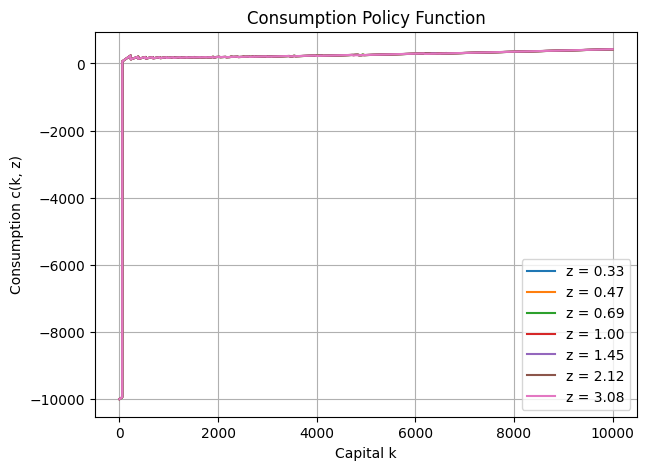

In [ ]:
### arbitrary z grid
## using vfi
plt.figure(figsize=(7,5))

for iz, z in enumerate(y):
    plt.plot(k_grid, c_new[:,iz], label=f'z = {z:.2f}')
   # plt.plot(k_grid_egm, c_analytical(params, k_grid_egm, z), label=f'Anal z={z:.2f}', linestyle='-')


plt.xlabel('Capital k')
plt.ylabel('Consumption c(k, z)')
plt.title('Consumption Policy Function')
plt.legend()
plt.grid(True)
plt.show()


## EGM

In [ ]:

def create_grid(params):
  """
  func : create the state space for the problem
  params : namedtuple with all the parameters
  creates the capital and idiosyncratic labor/income grid
  returns both grid and transistion and stationary distribution for idiosyncratic labor

  """

  ## non linear grid
  # a_uniform = np.linspace(0, 1, params.nbk)
  # a_transformed = a_uniform**2
  # k_grid = params.k_min + (params.k_max - params.k_min) * a_transformed## continous state/ discrete state

  ubar = np.log(1 + np.log(1 + params.k_max - params.k_min))
  a_uniform = np.linspace(0, ubar, params.nbk)
  k_grid = params.k_min + np.exp(np.exp(a_uniform) - 1) - 1

  return k_grid, Pi, pi


def euler_inv_RW_1(params, Pi, c_pol, r):
  """
  function : calculates the inverse of the euler equation
  params : namedtuple with all the parameters
  k_grid : grid for capital used in interpolant - np.array
  c_policy : consumption policy function used in interpolant - np.array

  """
  ## muc
  mu_c_arr = mu_c(params, c_pol) * (1+r)              #### dimesion - (nbk*nbn)
  expec = (Pi @ mu_c_arr.T).T

  return mu_c_inv(params, params.beta * expec)

### three different implementation of egm - 3rd fastest it seems.

## interpolate the c to get it as function of today's grid

### giving wrong results - beware

def solver_egm_1(params, r, k_grid, Pi, n_grid, tol = 1e-6, error = 1, iter = 0, max_iter = 1000):

  ## starting array for c
  c_old =  0.05*(y_grid[None, :] +  (1+r)*k_grid[:, None]) #### dimesion - (nbk*nbn)

  ## iteration
  for iter in range(max_iter):

    c_new = np.empty_like(c_old)
    k_new = np.empty_like(c_old)

    ## calculate the c - from euler equation
    c_1 = euler_inv_RW_1(params, Pi, c_old, r)              #### dimesion - (nbk*nbn)
    ## calculate the k - todays asset from budget equation
    k_1 = (k_grid[:, None] + c_1 - y_grid[None, :])/(1+r)

    ## evaluate c as a function of todays asset - earlier was defined on tomo asset
    for iy in range(params.nbn):
      c_new[:, iy] = np.interp(k_grid, k_1[:, iy], c_1[:, iy])

    k_new = y_grid[None, :] + (1+r)*k_grid[:, None] - c_new

    # borrowing constraint
    k_new = np.maximum(k_new, k_grid[0])

    error = np.max(np.abs(c_new - c_old))
    c_old[:] = c_new

    if error < tol:
      print(f"Converged in {iter} iterations")
      break
  return c_old, k_grid, y_grid, k_new

### interpolate to get saving policy - using cash on hands

def solver_egm_2(params, r, k_grid, Pi, y_grid, n_grid, tol = 1e-6, error = 1, iter = 0, max_iter = 1000):

  ## starting array for c
  c_old =  0.05*(y_grid[None, :] +  (1+r)*k_grid[:, None])  #### dimesion - (nbk*nbn)

  ## iteration
  for iter in range(max_iter):

    k_new = np.empty_like(c_old)

    ## calculate the c - from euler equation
    c_1 = euler_inv_RW_1(params, Pi, c_old, r)              #### dimesion - (nbk*nbn)
    ## calculate the k - from budget equation
    #print(z)
    coh = y_grid[None, :] +  (1+r)*k_grid[:, None]

    for iy in range(params.nbn):

      k_new[:,iy] = np.interp(coh[:,iy],c_1[:,iy]+k_grid,k_grid)

    # borrowing constraint
    k_new = np.maximum(k_new, k_grid[0])
    c_new = coh - k_new

    error = np.max(np.abs(c_new - c_old))
    c_old[:] = c_new

    if error < tol:
      print(f"Converged in {iter} iterations")
      break
  return c_old, k_grid, k_new


## interpolate to get saving polciy as function todays asset - similar to 2
def solver_egm_3(params, r, k_grid, Pi, y_grid, n_grid, tol = 1e-6, error = 1, iter = 0, max_iter = 1000):

  ## starting array for c
  c_old =  0.05*(y_grid[None, :] +  (1+r)*k_grid[:, None]) #### dimesion - (nbk*nbn)

  ## iteration
  for iter in range(max_iter):

    c_new = np.empty_like(c_old)
    k_new = np.empty_like(c_old)

    ## calculate the c - from euler equation
    c_1 = euler_inv_RW_1(params, Pi, c_old, r)              #### dimesion - (nbk*nbn)
    ## calculate the k - from budget equation
    #print(z)
    k_1 = (k_grid[:, None] + c_1 - y_grid[None, :])/(1+r)

    for iy in range(params.nbn):

      k_new[:, iy] = np.interp(k_grid, k_1[:, iy], k_grid)

    # borrowing constraint
    k_new = np.maximum(k_new, k_grid[0])
    c_new = y_grid[None, :] +  (1+r)*k_grid[:, None] - k_new

    error = np.max(np.abs(c_new - c_old))
    c_old[:] = c_new

    if error < tol:
      print(f"Converged in {iter} iterations")
      break
  return c_old, k_grid, k_new

class Baseline_Huggett_1:

    def __init__(self, params, Pi, pi, y_grid, n_grid, r):
        """
        class creates a solver for an aiyagari economy using EGM
        """
        self.params = params
        self.r = r
        self.Pi = Pi
        self.pi = pi
        self.y_grid = y_grid


    def EGM_1(self, params, Pi, pi, y_grid, n_grid, r, tol = 10**-6, max_iter = 1000):

      k_grid, Pi, pi = create_grid(params)
      ## return the policy functions through njit class
      return solver_egm_3(params, r, k_grid, Pi, y_grid, n_grid, tol = 1e-6, error = 1, iter = 0, max_iter = 1000), Pi, pi



In [ ]:
## function
start = time()

Pi,pi,n_grid =  discretize_state(params)

 ## making it like huggett/ bewley
y_grid = (1-params.r*params.B)*n_grid                       ### dimesion - (nbn*1)

Baseline_Huggett_model = Baseline_Huggett_1(params, Pi, pi, y_grid, n_grid, r=params.r)
solution, Pi, pi = Baseline_Huggett_model.EGM_1(params,Pi,pi, y_grid, n_grid, r=params.r)

c_old, k_grid, k_new = solution
end = time()
print("Time of execution: "+str(end-start))

Converged in 239 iterations
Time of execution: 0.045522451400756836


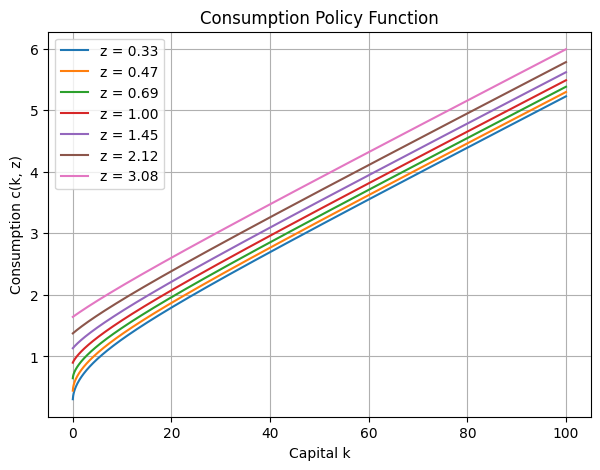

In [ ]:

### using egm 1

plt.figure(figsize=(7,5))

for iz, z in enumerate(n_grid):
    plt.plot(k_grid, c_old[:,iz], label=f'z = {z:.2f}')
   # plt.plot(k_grid_egm, c_analytical(params, k_grid_egm, z), label=f'Anal z={z:.2f}', linestyle='-')


plt.xlabel('Capital k')
plt.ylabel('Consumption c(k, z)')
plt.title('Consumption Policy Function')
plt.legend()
plt.grid(True)
plt.show()


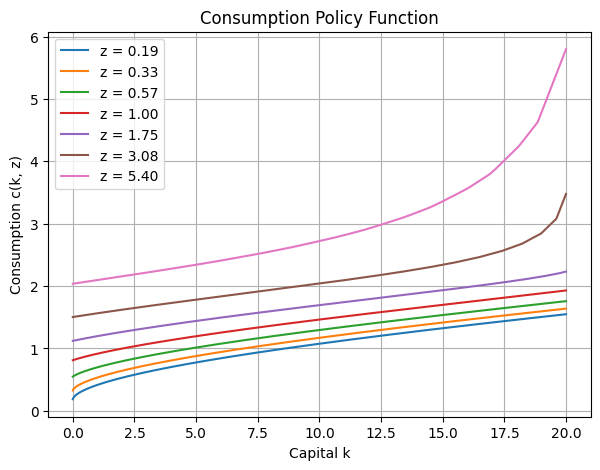

In [ ]:

## using egm 2
## Time of execution: 0.1009972095489502

plt.figure(figsize=(7,5))

for iz, z in enumerate(n_grid):
    plt.plot(k_grid, c_old[:,iz], label=f'z = {z:.2f}')
   # plt.plot(k_grid_egm, c_analytical(params, k_grid_egm, z), label=f'Anal z={z:.2f}', linestyle='-')


plt.xlabel('Capital k')
plt.ylabel('Consumption c(k, z)')
plt.title('Consumption Policy Function')
plt.legend()
plt.grid(True)
plt.show()


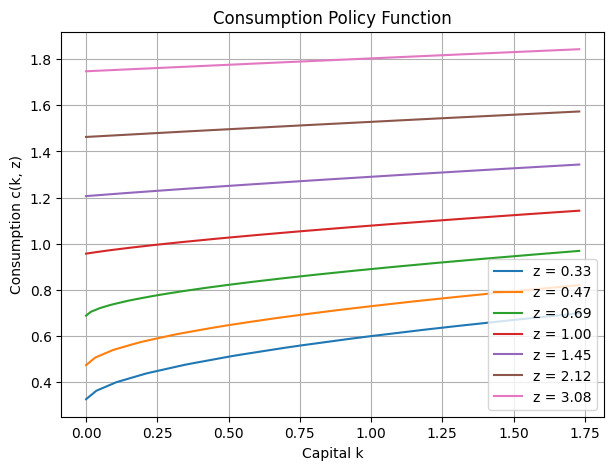

In [ ]:

### using egm 3
## Time of execution: 0.09975862503051758

plt.figure(figsize=(7,5))

for iz, z in enumerate(n_grid):
    plt.plot(k_grid[:300], c_old[:,iz][:300], label=f'z = {z:.2f}')
   # plt.plot(k_grid_egm, c_analytical(params, k_grid_egm, z), label=f'Anal z={z:.2f}', linestyle='-')


plt.xlabel('Capital k')
plt.ylabel('Consumption c(k, z)')
plt.title('Consumption Policy Function')
plt.legend()
plt.grid(True)
plt.show()


## Asset Distribution

In [ ]:

def transition_matrix_vectorized(Pi, pol_idx, k_grid, z_grid):
    Na = len(k_grid)
    Nz = len(z_grid)

    a_idx = np.arange(Na).reshape(1, 1, Na, 1)
    pol = pol_idx.reshape(Na, Nz, 1, 1)

    a_indicator = (pol == a_idx).astype(float)
    Pi_re = Pi.reshape(1, Nz, 1, Nz)

    P = a_indicator * Pi_re
    return P.reshape(Na * Nz, Na * Nz)


def transition_matrix_sparse_fast(Pi, pol_idx):
    Na, Nz = pol_idx.shape

    rows = np.repeat(np.arange(Na * Nz), Nz)

    a_next = pol_idx.flatten()
    z = np.tile(np.arange(Nz), Na)
    zp = np.tile(np.arange(Nz), Na * Nz)

    cols = a_next.repeat(Nz) * Nz + zp
    data = Pi[z.repeat(Nz), zp]

    return coo_matrix((data, (rows, cols)),
                      shape=(Na * Nz, Na * Nz))



def stationary_distribution_hugett(Pi, pi, pol_idx, k_new, k_grid, z_grid, graphs = True):

  k_num = len(k_grid)
  z_num = len(z_grid)

  ### compute the actual distribution for the asset supply
  transition = transition_matrix_sparse_fast(Pi, pol_idx)

  ## using eigen_vector method
  initial = np.outer(np.ones(k_num)/k_num, pi).reshape(k_num*z_num,1)
  T_stat = stationary_distribution_stable(transition,initial)
  T_stat = T_stat.reshape(k_num,z_num)

  ## distribution of asset - summing across z
  a_dist = T_stat.sum(axis=1)

  ## conditional distribution for different z
  T_cond = T_stat / T_stat.sum(axis=0, keepdims=True)

  ### check distribution of asset supply
  if not np.isclose(a_dist.sum(), 1.0):
    ValueError("mass of probability not equal to 1 !!")
  a_mean = np.vdot(k_new, T_stat)

  if graphs:
    ## statistics of asset distribution
    E_a_squared = np.dot(k_grid.ravel()**2, a_dist.ravel())
    std_assets = np.sqrt(E_a_squared - a_mean**2)

    cdf = np.cumsum(a_dist)
    q25_idx = int(0.25 * k_num)      # 0-999, OK
    median_idx = int(0.5 * k_num)
    q75_idx = int(0.75 * k_num)
    q100_idx = k_num - 1              # last element

    q25_assets = k_grid[q25_idx]
    median_assets = k_grid[median_idx]
    q75_assets = k_grid[q75_idx]

    frac_at_constraint = a_dist[0]

    stats = {
          'mean': a_mean,
          'std': std_assets,
          'median': median_assets,
          'q25': q25_assets,
          'q75': q75_assets,
          'frac_at_constraint': frac_at_constraint
      }

      # plotting distribution of asset
    fig, ax = plt.subplots(1,3, figsize = (12,8))
    ax[0].bar(k_grid.ravel(),a_dist.ravel())
    ax[0].axvline(x=stats['mean'], color='red', linestyle='--', label='Mean')
    ax[0].axvline(x=stats['median'], color='green', linestyle='--', label='Median')
    ax[0].legend()
    ax[0].set_xlim(0, 6)
    ax[0].set_title("Asset Distribution")
    ax[0].set_xlabel("Assets")
    ax[0].set_ylabel("Probability Mass")


    ax[1].plot(k_grid,cdf)
    ax[1].axhline(y=1.0, color='red', linestyle='--')
    ax[1].set_title ("Cumulative Distribution")
    ax[1].set_xlabel("Assets")
    ax[1].set_ylabel("Cumulative Probability")

    for z in range(z_num):
      ax[2].plot(k_grid[:10], T_cond[:,z][:10], label=f'z = {z_grid[z]:.2f}')
    ax[2].legend()
    ax[2].set_xlabel('Assets a')
    ax[2].set_ylabel('Probability')
    plt.show()
    return a_dist, T_stat, a_mean, stats
  else:
    return a_dist, T_stat, a_mean


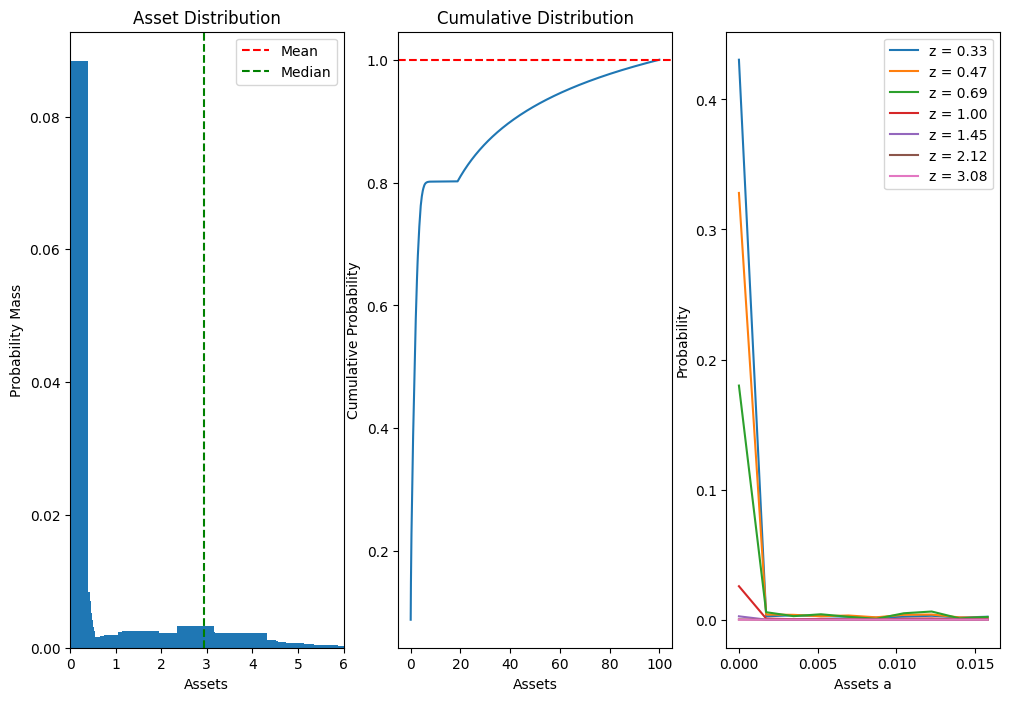

In [ ]:
### for cont state space using rouwenhorst
## using vfi
a_dist, T_stat, a_mean, stats = stationary_distribution_hugett(Pi,pi,pol_idx,k_new,k_grid,n_grid)

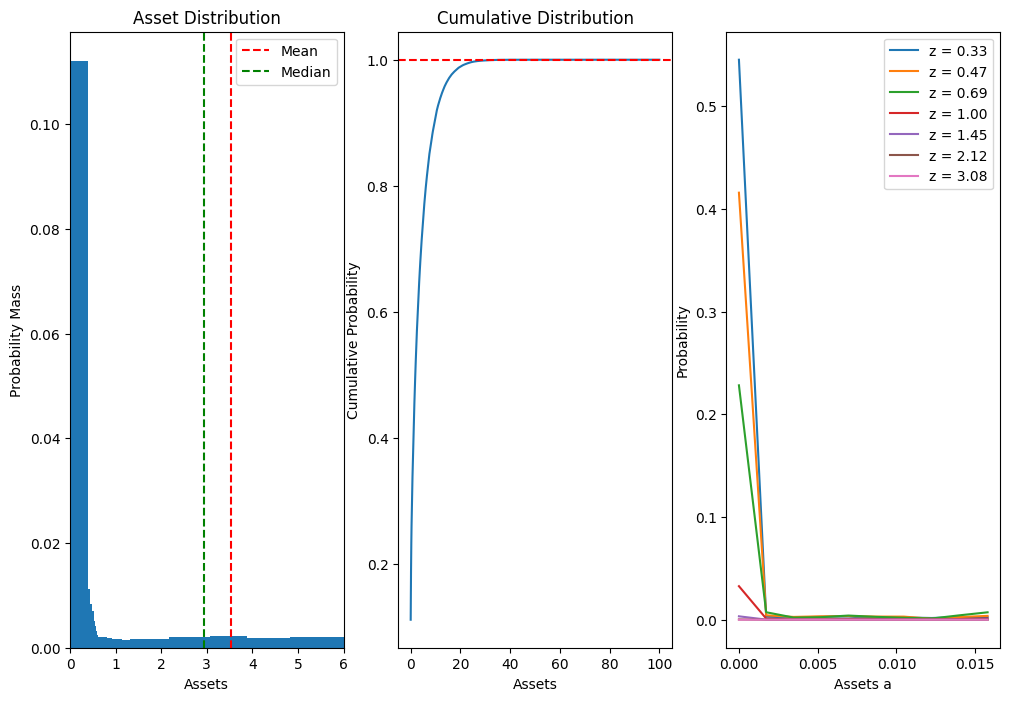

In [ ]:
### for cont state space using rouwenhorst
## using egm 3
pol_idx = np.searchsorted(k_grid, k_new)
pol_idx = np.clip(pol_idx, 0, len(k_grid)-1)
a_dist, T_stat, a_mean, stats = stationary_distribution_hugett(Pi,pi,pol_idx,k_new,k_grid,n_grid)

In [ ]:
for e, ye in enumerate(n_grid):
    print(f'Ave assets at y={ye:.2f}: {np.vdot(k_grid, T_stat[:,e]) / pi[e]:.2f}')

Ave assets at y=0.33: 0.97
Ave assets at y=0.47: 1.37
Ave assets at y=0.69: 2.02
Ave assets at y=1.00: 3.10
Ave assets at y=1.45: 4.77
Ave assets at y=2.12: 7.20
Ave assets at y=3.08: 10.55


In [ ]:
for e, ye in enumerate(n_grid):
    print(f'Total assets at y={ye:.2f} ({100*pi[e]:.1f}% of hh)\t: {np.vdot(k_grid, T_stat[:,e]):.2f}')

Total assets at y=0.33 (1.6% of hh)	: 0.02
Total assets at y=0.47 (9.4% of hh)	: 0.13
Total assets at y=0.69 (23.4% of hh)	: 0.47
Total assets at y=1.00 (31.2% of hh)	: 0.97
Total assets at y=1.45 (23.4% of hh)	: 1.12
Total assets at y=2.12 (9.4% of hh)	: 0.67
Total assets at y=3.08 (1.6% of hh)	: 0.16


In [ ]:
np.sum(k_grid.reshape(-1,1)*T_stat)

np.float64(3.54298569049119)

In [ ]:
np.vdot(k_new,T_stat)

np.float64(3.531547246916901)

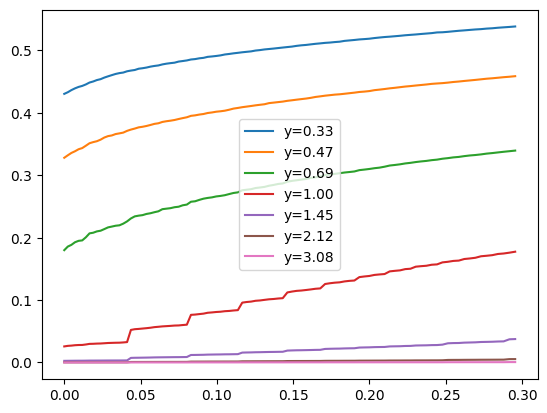

In [ ]:
for e, ye in enumerate(n_grid):
    plt.plot(k_grid[:100], T_stat[:,e][:100].cumsum()/pi[e], label=f'y={ye:.2f}')
plt.legend()

## General Equilibrium with govt

In [ ]:
def Huggett_Eql_num(ir, params, Pi, pi, n_grid, egm = True):
  ## making it like huggett/ bewley
  y_grid = (1-ir*params.B)*n_grid                       ### dimesion - (nbn*1)

  if egm:
    Baseline_Huggett_model = Baseline_Huggett_1(params, Pi, pi, y_grid, n_grid, r=ir)
    solution, Pi, pi = Baseline_Huggett_model.EGM_1(params, Pi, pi, y_grid, n_grid, r=ir)

    c_old, k_grid, k_new = solution
    pol_idx = np.searchsorted(k_grid, k_new)
    pol_idx = np.clip(pol_idx, 0, len(k_grid)-1)
  else :
    Huggett_model = HM(params)
    solution = Huggett_model.SVFI_HM()
    k_grid, k_new, c_new, pol_idx, v_1, n_grid , Pi, pi = solution

  a_mean = stationary_distribution_hugett(Pi, pi, pol_idx, k_new, k_grid, y_grid, graphs = False)[2]
  print(a_mean)

  return a_mean - params.B

In [ ]:
1/params.beta -1

0.04166666666666674

In [ ]:
r_eql = opt.brentq(Huggett_Eql_num, -0.1, 0.3, args=(params, Pi, pi, n_grid, True)) # Pass params and egm=True
print("equilirbium interest rate:", r_eql)

Converged in 36 iterations
0.0
Converged in 32 iterations
100.00000000000166
Converged in 40 iterations
0.0
Converged in 84 iterations
99.99999963633118
Converged in 42 iterations
0.00015735350679487172
Converged in 133 iterations
0.5934334756917459
Converged in 166 iterations
99.99989138708267
Converged in 134 iterations
0.619649616967145
Converged in 255 iterations
8.847478796166104
Converged in 146 iterations
0.8067581269720798
Converged in 187 iterations
1.6862156262528263
Converged in 205 iterations
2.242234743358407
Converged in 197 iterations
2.002186688755721
Converged in 197 iterations
1.9978519550425073
Converged in 197 iterations
2.0003543938913717
Converged in 197 iterations
1.9987111917162566
Converged in 197 iterations
2.0003527009113147
Converged in 197 iterations
2.000349622526808
Converged in 197 iterations
2.0000852448403004
Converged in 197 iterations
2.0000848341166853
Converged in 197 iterations
2.000084269959064
Converged in 197 iterations
1.9987114736954044
Conve

In [ ]:
1/params.beta - 1

0.04166666666666674

## Steady State and Comparative statics

In [ ]:
def steady_state(params, Pi, pi, y_grid, r):
  Baseline_Huggett_model = Baseline_Huggett_1(params, Pi, pi, y_grid, n_grid, r)
  solution, Pi, pi = Baseline_Huggett_model.EGM_1(params, Pi, pi, y_grid, n_grid, r)

  c_old, k_grid, k_new = solution
  pol_idx = np.searchsorted(k_grid, k_new)
  pol_idx = np.clip(pol_idx, 0, len(k_grid)-1)
  a_dist, T_stat, a_mean = stationary_distribution_hugett(Pi, pi, pol_idx, k_new, k_grid, y_grid, graphs = False)

  return dict(Pi = Pi, pi = pi, a_dist = a_dist, T_stat = T_stat, a_mean = a_mean, c_old = c_old, k_grid = k_grid, y_grid = y_grid, n_grid = n_grid, k_new = k_new )



Converged in 178 iterations
Converged in 196 iterations
Converged in 200 iterations
Converged in 198 iterations
Converged in 190 iterations


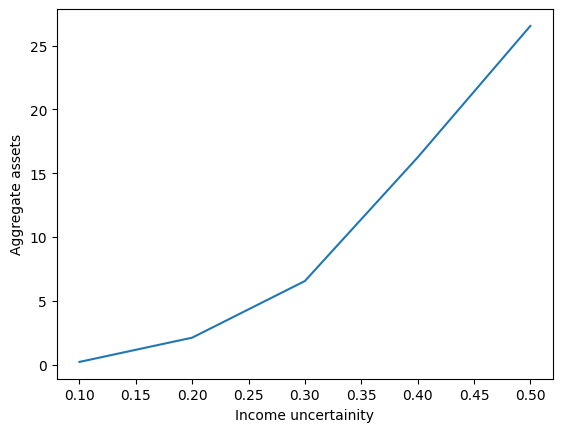

In [ ]:
#rs = r + np.linspace(-0.02, 0.015, 15)
## increasing uncertanity - increasing savings - precautionary savings
sigmas = np.linspace(0.1, 0.5, 5)
AS  = []

for s in sigmas:
  p = params._replace(sigma=s)
  Pi, pi, n_grid =  discretize_state(p)
  AS.append(steady_state(p,Pi,pi,n_grid,r_eql)['a_mean'])

plt.plot(sigmas, AS)
plt.xlabel('Income uncertainity')
plt.ylabel('Aggregate assets');


In [ ]:
1/(params.r+1)

0.970873786407767

Converged in 69 iterations
Converged in 78 iterations
Converged in 90 iterations
Converged in 106 iterations
Converged in 129 iterations
Converged in 166 iterations
Converged in 237 iterations
Converged in 300 iterations
Converged in 272 iterations
Converged in 191 iterations


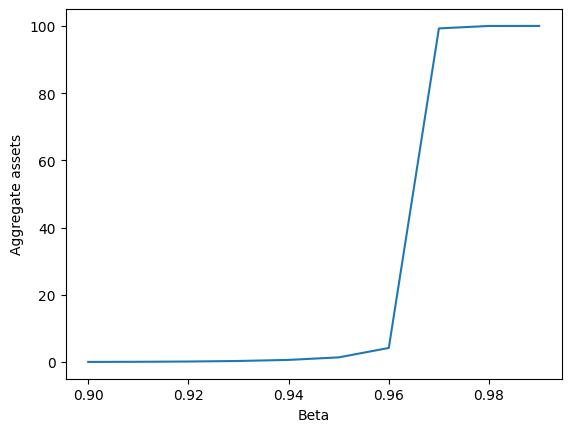

In [ ]:
#rs = r + np.linspace(-0.02, 0.015, 15)
## increasing uncertanity - increasing savings - precautionary savings
betas = np.linspace(0.9, 0.99, 10)
AS  = []

for b in betas:
  p = params._replace(beta=b)
  Pi, pi, n_grid =  discretize_state(p)
  AS.append(steady_state(p,Pi,pi,n_grid,params.r)['a_mean'])

plt.plot(betas, AS)
plt.xlabel('Beta')
plt.ylabel('Aggregate assets');


## Calibration

## Dynamics : Finding equilibrium

### Iteration

In [ ]:
## initial steady state = final steady state - MIT shock
Pi, pi, n_grid =  discretize_state(params)

## making it like huggett/ bewley
y_grid = (1-params.r*params.B)*n_grid                       ### dimesion - (nbn*1)

ss = steady_state(params, Pi, pi, y_grid, r_eql)

Converged in 197 iterations


In [ ]:
ss.keys()

dict_keys(['Pi', 'pi', 'a_dist', 'T_stat', 'a_mean', 'c_old', 'k_grid', 'y_grid', 'n_grid', 'k_new'])

In [ ]:
def backward_iteration(params, c_1, y_grid, k_grid, r):

  ## calculate the c - from euler equation
  c_new = euler_inv_RW_1(params, Pi, c_1, r)              #### dimesion - (nbk*nbn)
  k_new = np.empty_like(c_new)
  ## calculate the k - from budget equation

  k_1 = (k_grid[:, None] + c_new - y_grid[None, :])/(1+r)

  for iy in range(params.nbn):

    k_new[:, iy] = np.interp(k_grid, k_1[:, iy], k_grid)

  # borrowing constraint
  k_new = np.maximum(k_new, k_grid[0])
  pol_idx = np.searchsorted(k_grid, k_new)
  pol_idx = np.clip(pol_idx, 0, len(k_grid)-1)
  c_0 = y_grid[None, :] +  (1+r)*k_grid[:, None] - k_new

  return c_0, k_new, pol_idx      #### dimesion - (nbk*nbn), (nbk*nbn), (nbk*nbn)

def forward_iteration(T_0, Pi, pol_idx):
    Na, Nz = pol_idx.shape

    rows = np.repeat(np.arange(Na * Nz), Nz)

    a_next = pol_idx.flatten()
    z = np.tile(np.arange(Nz), Na)
    zp = np.tile(np.arange(Nz), Na * Nz)

    cols = a_next.repeat(Nz) * Nz + zp
    data = Pi[z.repeat(Nz), zp]

    P = coo_matrix((data, (rows, cols)),
                      shape=(Na * Nz, Na * Nz))
    T_1 = P.T @ T_0
    T_1 = T_1.reshape(Na, Nz)
    return T_1


In [ ]:
eps = 1e-04
def policy_impulse(params, ss_new, shocks, T, rs):

  c_0 = np.empty((T, *ss_new['c_old'].shape))     ### dimension - T*nbk*nbn
  in_c = ss_new['c_old']                          ### dimension - T*nbk*nbn
  k_new = np.empty_like(c_0)                      ### dimension - T*nbk*nbn
  pol_idx_t = np.empty_like(c_0)                  ### dimension - T*nbk*nbn

  path = shocks['y_t']
  for t in reversed(range(T)):

    y_t = path[t]

    c_0[t], k_new[t], pol_idx_t[t]  =  backward_iteration(params, in_c, y_t , ss_new['k_grid'], rs[t])
    in_c = c_0[t]


  return c_0, k_new, pol_idx_t


def distribution_impulse(ss_old, k_new, pol_idx, shocks, T):

  """
  func: estimate distirbution by iterating forward over time, T
  ss_old : dict for old steady state
  k_new : new policy function for t th time
  pol_idx : index of policy function
  shocks : dict of shocks
  T : time horizon

  """
  T_1 = np.empty((T, *ss_old['T_stat'].shape))

  in_T = ss['T_stat'].reshape(-1,1)

  path = shocks['y_t']

  for t in range(T):
    y_t = path[t]
    pol_idx_t = pol_idx[t]
    k_new_t = k_new[t]
    T_1[t] = forward_iteration(in_T, ss_old['Pi'], pol_idx_t)
    in_T = T_1[t].reshape(-1,1)

  return T_1



def household_impulse(params, ss_old, ss_new, shocks, T, rs):

  """
  func: returns full path of distribution and policy impulse over time
  ss_old : dict for old steady state
  ss_new : dict for new steady state
  shocks : dict of shocks
  T : time horizon
  params : parameters
  rs : array of interest rate for T periods
  """
  c_0_dy, k_new_dy, pol_idx_t  = policy_impulse(params, ss_new, shocks, T, rs)
  T_1 = distribution_impulse(ss_old, k_new_dy, pol_idx_t, shocks, T)


  return c_0_dy, k_new_dy, pol_idx_t, T_1


def economy_impulse(params, ss_old, ss_new, shocks, T, rs):

  """
  func: path of interest rate over time such that market clears
  ss_old : dict for old steady state
  ss_new : dict for new steady state
  shocks : dict of shocks
  T : time horizon
  params : parameters
  rs : array of interest rate for T periods
  """

  c_0_dy, k_new_dy, pol_idx_t, T_1 = household_impulse(params, ss_old, ss_new, shocks, T, rs)
  c_0 = ss_new['c_old']
  k_0 = ss_new['k_new']

  c_impulse = 100*(impulse[0] - c_0)/(c_0 + eps)
  k_impulse = 100*(impulse[1] - k_0)/(k_0 + eps)
  a_mean_t = np.sum(impulse[1]*T_1, axis=(1,2))
  c_mean_t = np.sum(*impulse[3], axis=(1,2))

  asset_mkt_error = a_mean_t - params.B

  return c_impulse, k_impulse, a_mean_t, c_mean_t, asset_mkt_error

## income = yt = (Xt - tau_t)*e, e is the markov idiosyncratic, imagine some linear labor only production
## original --- yt = 1*n_grid // yt = (1-tau_t)*n_grid  = (1-rt*B)*n_grid
## govt budget balanced - tau_t = rt*B
## study productivity shock - MIT shock / tax increase

def equilirbium_iteration_mit(params, ss_old, ss_new, T, r, updation = 0.002):

  """
  func: keep r fixed and then updated so that error becomes 0 : equilibrium when not in steady state
        such that every period the A0,A1,A2 ... = B,B,B,...
  r : interest rate preferably last ss eql int rate
  """

  Xt = params.Xbar + 0.01*params.sh_rho**np.arange(T)  ### steady state value, default = 1
  tau_t = np.full(T, params.r*params.B) ### kept the r fixed
  ys = np.outer(Xt - tau_t, ss_old['n_grid'])

  ## starting equlibrium variable - r
  rs = np.full(T, r)

  for iter in range(100):

    c_impulse, k_impulse, a_mean_t, c_mean_t, asset_mkt_error = economy_impulse(params, ss_old, ss_new, {'y_t': ys}, T, rs)

    if iter % 10 == 0 and iter <= 100:
        plt.plot(asset_mkt_error, label=f'iteration {iter}')
    if np.max(np.abs(asset_mkt_error)) < 5E-4:
        print(f'Converged to 0.0005 accuracy after {iter} iterations')
        break
    rs[1:] -= updation*asset_mkt_error[:-1]


  return rs



In [ ]:
eps = 1e-04
def policy_impulse(params, ss_new, shocks, T, rs):

  c_0 = np.empty((T, *ss_new['c_old'].shape))     ### dimension - T*nbk*nbn
  in_c = ss_new['c_old']                          ### dimension - T*nbk*nbn
  k_new = np.empty_like(c_0)                      ### dimension - T*nbk*nbn
  pol_idx_t = np.empty_like(c_0)                  ### dimension - T*nbk*nbn

  path = shocks['y_t']
  for t in reversed(range(T)):

    y_t = path[t]

    c_0[t], k_new[t], pol_idx_t[t]  =  backward_iteration(params, in_c, y_t , ss_new['k_grid'], rs[t])
    in_c = c_0[t]


  return c_0, k_new, pol_idx_t


def distribution_impulse(ss_old, k_new, pol_idx, shocks, T):

  """
  func: estimate distirbution by iterating forward over time, T
  ss_old : dict for old steady state
  k_new : new policy function for t th time
  pol_idx : index of policy function
  shocks : dict of shocks
  T : time horizon

  """
  T_1 = np.empty((T, *ss_old['T_stat'].shape))

  in_T = ss['T_stat'].reshape(-1,1)

  path = shocks['y_t']

  for t in range(T):
    y_t = path[t]
    pol_idx_t = pol_idx[t]
    k_new_t = k_new[t]
    T_1[t] = forward_iteration(in_T, ss_old['Pi'], pol_idx_t)
    in_T = T_1[t].reshape(-1,1)

  return T_1



def household_impulse(params, ss_old, ss_new, shocks, T, rs):

  """
  func: returns full path of distribution and policy impulse over time
  ss_old : dict for old steady state
  ss_new : dict for new steady state
  shocks : dict of shocks
  T : time horizon
  params : parameters
  rs : array of interest rate for T periods
  """
  c_0_dy, k_new_dy, pol_idx_t  = policy_impulse(params, ss_new, shocks, T, rs)
  T_1 = distribution_impulse(ss_old, k_new_dy, pol_idx_t, shocks, T)


  return c_0_dy, k_new_dy, pol_idx_t, T_1


def economy_impulse(params, ss_old, ss_new, shocks, T, rs):

  """
  func: path of interest rate over time such that market clears
  ss_old : dict for old steady state
  ss_new : dict for new steady state
  shocks : dict of shocks
  T : time horizon
  params : parameters
  rs : array of interest rate for T periods
  """

  c_0_dy, k_new_dy, pol_idx_t, T_1 = household_impulse(params, ss_old, ss_new, shocks, T, rs)
  c_0 = ss_new['c_old']
  k_0 = ss_new['k_new']

  c_impulse = 100*(c_0_dy - c_0)/(c_0 + eps)
  k_impulse = 100*(k_new_dy - k_0)/(k_0 + eps)
  a_mean_t = np.sum(c_0_dy*T_1, axis=(1,2))
  c_mean_t = np.sum(c_0_dy*T_1, axis=(1,2))

  asset_mkt_error = a_mean_t - params.B

  return c_impulse, k_impulse, a_mean_t, c_mean_t, asset_mkt_error


In [ ]:
## income = yt = (Xt - tau_t)*e, e is the markov idiosyncratic, imagine some linear labor only production
## original --- yt = 1*n_grid // yt = (1-tau_t)*n_grid  = (1-rt*B)*n_grid
## govt budget balanced - tau_t = rt*B
## study productivity shock - MIT shock / tax increase

def equilirbium_iteration_mit(params, ss_old, ss_new, T, r, updation = 0.002):

  """
  func: keep r fixed and then updated so that error becomes 0 : equilibrium when not in steady state
        such that every period the A0,A1,A2 ... = B,B,B,...
  r : interest rate preferably last ss eql int rate
  """

  Xt = params.Xbar + 0.01*params.sh_rho**np.arange(T)  ### steady state value, default = 1
  tau_t = np.full(T, params.r*params.B) ### kept the r fixed
  ys = np.outer(Xt - tau_t, ss_old['n_grid'])

  ## starting equlibrium variable - r
  rs = np.full(T, r)

  for iter in range(100):

    c_impulse, k_impulse, a_mean_t, c_mean_t, asset_mkt_error = economy_impulse(params, ss_old, ss_new, {'y_t': ys}, T, rs)

    if iter % 10 == 0 and iter <= 100:
        plt.plot(asset_mkt_error, label=f'iteration {iter}')
        plt.legend()
    if np.max(np.abs(asset_mkt_error)) < 5E-4:
        print(f'Converged to 0.0005 accuracy after {iter} iterations')
        break
    rs[1:] -= updation*asset_mkt_error[:-1]


  return rs


In [ ]:
T = 300
c_0_dy, k_new_dy, pol_idx_t  = policy_impulse(params, ss, {'r': np.full(T, params.r-0.001)}, T)

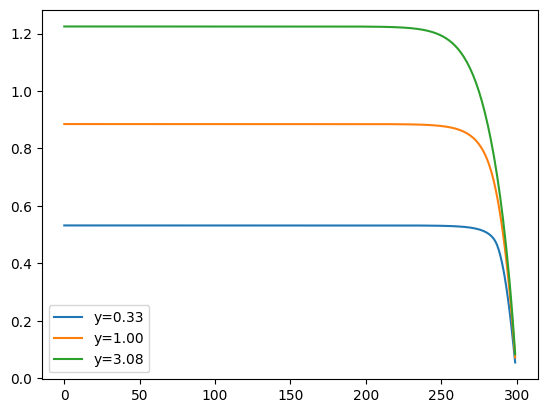

In [ ]:

i_ave = np.argmax(ss['k_grid'] > ss['a_mean'])
for e in (0, 3, 6):
    plt.plot(c_impulse[:, i_ave, e], label=f"y={ss['n_grid'][e]:.2f}")

plt.legend()

In [ ]:
Xt = 1 + 0.01*0.95**np.arange(300)  ### steady state value, default = 1
tau_t = np.full(300, params.r*params.B) ### kept the r fixed
ys = np.outer(Xt - tau_t, ss['n_grid'])

array([0.02417835, 0.02715778, 0.02506081, 0.02475109, 0.02438305,
       0.02417678, 0.02406485, 0.02399012, 0.02395341, 0.02393994,
       0.02394722, 0.02396149, 0.02397996, 0.02400227, 0.02402222,
       0.02404326, 0.02406403, 0.02408374, 0.02410069, 0.02411513,
       0.02412716, 0.02413655, 0.02414546, 0.02415398, 0.02416109,
       0.02416832, 0.02417632, 0.02418278, 0.02418912, 0.02419502,
       0.02419817, 0.02420114, 0.0242072 , 0.02421369, 0.02422141,
       0.02422743, 0.02423212, 0.02423632, 0.02424088, 0.02424704,
       0.02425418, 0.02425936, 0.02426203, 0.02426614, 0.02426912,
       0.02427162, 0.02427366, 0.02427543, 0.02427801, 0.02428058,
       0.02428286, 0.02428611, 0.02428896, 0.02429236, 0.02429601,
       0.02429723, 0.02429659, 0.02429685, 0.02429788, 0.02429861,
       0.02429988, 0.02430116, 0.02430195, 0.02430272, 0.02430371,
       0.02430479, 0.02430598, 0.02430697, 0.02430851, 0.02431002,
       0.02431076, 0.02431129, 0.02431115, 0.02431101, 0.02431

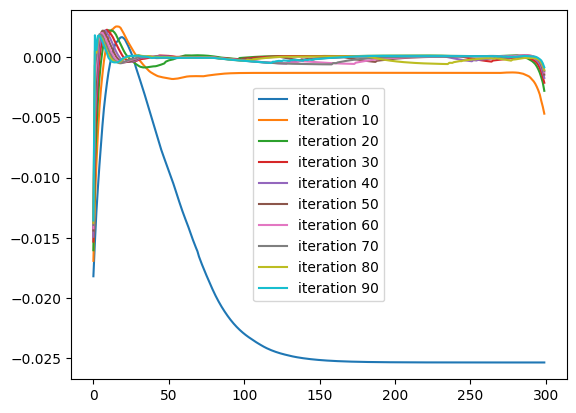

In [ ]:
equilirbium_iteration_mit(params, ss, ss, T = 300, r = r_eql, updation = 0.002)

### Sequence space jacobian

#### Brute force method

#### Fake news algo

## Cont time HJB - explicit method

## Cont time HJB - implicit method

# Hugett model with labor

## EGM

In [ ]:

def create_grid(params):
  """
  func : create the state space for the problem
  params : namedtuple with all the parameters
  creates the capital and idiosyncratic labor/income grid
  returns both grid and transistion and stationary distribution for idiosyncratic labor

  """

  ## non linear grid
  # a_uniform = np.linspace(0, 1, params.nbk)
  # a_transformed = a_uniform**2
  # k_grid = params.k_min + (params.k_max - params.k_min) * a_transformed## continous state/ discrete state

  ubar = np.log(1 + np.log(1 + params.k_max - params.k_min))
  a_uniform = np.linspace(0, ubar, params.nbk)
  k_grid = params.k_min + np.exp(np.exp(a_uniform) - 1) - 1

  return k_grid, Pi, pi


def euler_inv_RW_1(params, Pi, c_pol, r):
  """
  function : calculates the inverse of the euler equation
  params : namedtuple with all the parameters
  k_grid : grid for capital used in interpolant - np.array
  c_policy : consumption policy function used in interpolant - np.array

  """
  ## muc
  mu_c_arr = mu_c(params, c_pol) * (1+r)              #### dimesion - (nbk*nbn)
  expec = (Pi @ mu_c_arr.T).T

  return mu_c_inv(params, params.beta * expec)

### implementation of egm


## interpolate to get saving polciy as function todays asset - similar to 2
def solver_egm_3(params, r, k_grid, Pi, y_grid, n_grid, tol = 1e-6, error = 1, iter = 0, max_iter = 1000):

  ## starting array for c
  c_old =  0.05*(y_grid[None, :] +  (1+r)*k_grid[:, None]) #### dimesion - (nbk*nbn)

  ## iteration
  for iter in range(max_iter):

    c_new = np.empty_like(c_old)
    k_new = np.empty_like(c_old)

    ## calculate the c - from euler equation
    c_1 = euler_inv_RW_1(params, Pi, c_old, r)              #### dimesion - (nbk*nbn)
    ## calculate the k - from budget equation
    #print(z)
    k_1 = (k_grid[:, None] + c_1 - y_grid[None, :])/(1+r)

    for iy in range(params.nbn):

      k_new[:, iy] = np.interp(k_grid, k_1[:, iy], k_grid)

    # borrowing constraint
    k_new = np.maximum(k_new, k_grid[0])
    c_new = y_grid[None, :] +  (1+r)*k_grid[:, None] - k_new

    error = np.max(np.abs(c_new - c_old))
    c_old[:] = c_new

    if error < tol:
      print(f"Converged in {iter} iterations")
      break
  return c_old, k_grid, k_new

class Baseline_Huggett_1:

    def __init__(self, params, Pi, pi, y_grid, n_grid, r):
        """
        class creates a solver for an aiyagari economy using EGM
        """
        self.params = params
        self.r = r
        self.Pi = Pi
        self.pi = pi
        self.y_grid = y_grid


    def EGM_1(self, params, Pi, pi, y_grid, n_grid, r, tol = 10**-6, max_iter = 1000):

      k_grid, Pi, pi = create_grid(params)
      ## return the policy functions through njit class
      return solver_egm_3(params, r, k_grid, Pi, y_grid, n_grid, tol = 1e-6, error = 1, iter = 0, max_iter = 1000), Pi, pi



In [ ]:
## function
start = time()

Pi,pi,n_grid =  discretize_state(params)

 ## making it like huggett/ bewley
y_grid = (1-params.r*params.B)*n_grid                       ### dimesion - (nbn*1)

Baseline_Huggett_model = Baseline_Huggett_1(params, Pi, pi, y_grid, n_grid, r=params.r)
solution, Pi, pi = Baseline_Huggett_model.EGM_1(params,Pi,pi, y_grid, n_grid, r=params.r)

c_old, k_grid, k_new = solution
end = time()
print("Time of execution: "+str(end-start))

Converged in 239 iterations
Time of execution: 0.045522451400756836


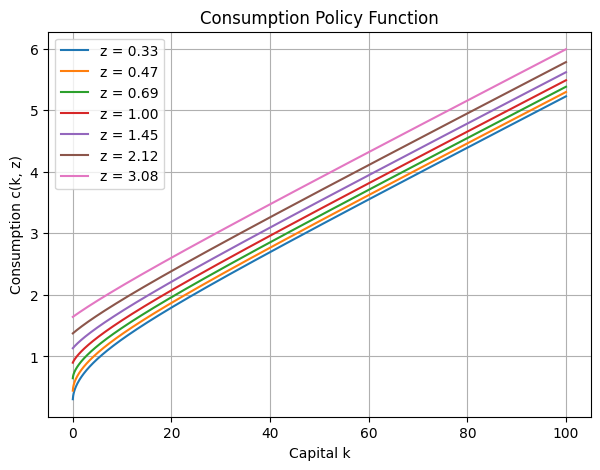

In [ ]:

### using egm 1

plt.figure(figsize=(7,5))

for iz, z in enumerate(n_grid):
    plt.plot(k_grid, c_old[:,iz], label=f'z = {z:.2f}')
   # plt.plot(k_grid_egm, c_analytical(params, k_grid_egm, z), label=f'Anal z={z:.2f}', linestyle='-')


plt.xlabel('Capital k')
plt.ylabel('Consumption c(k, z)')
plt.title('Consumption Policy Function')
plt.legend()
plt.grid(True)
plt.show()


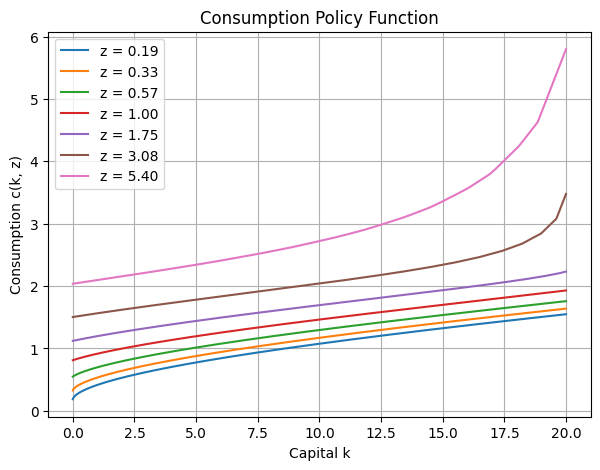

In [ ]:

## using egm 2
## Time of execution: 0.1009972095489502

plt.figure(figsize=(7,5))

for iz, z in enumerate(n_grid):
    plt.plot(k_grid, c_old[:,iz], label=f'z = {z:.2f}')
   # plt.plot(k_grid_egm, c_analytical(params, k_grid_egm, z), label=f'Anal z={z:.2f}', linestyle='-')


plt.xlabel('Capital k')
plt.ylabel('Consumption c(k, z)')
plt.title('Consumption Policy Function')
plt.legend()
plt.grid(True)
plt.show()
